# DL Lab Assignment - 9

### CS22B1093 Rohan G

-----------------------

In [ ]:
# Importing necessary libraries
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class BrainMRIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and mask in RGB
        image = Image.open(self.image_paths[idx]).convert("RGB")  
        mask = Image.open(self.mask_paths[idx]).convert("L")  # Keep mask as grayscale
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
            mask = transforms.ToTensor()(mask)  # Convert mask to tensor separately

        return image, mask

# Training and validation datasets
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [ ]:
# Load dataset paths
import os
import glob
from sklearn.model_selection import train_test_split

dataset_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m/"

# Get all image paths (excluding masks)
image_paths = sorted(glob.glob(os.path.join(dataset_path, "*/*.tif")))
image_paths = [p for p in image_paths if not p.endswith("_mask.tif")]

# Generate corresponding mask paths
mask_paths = [p.replace(".tif", "_mask.tif") for p in image_paths]

# Ensure masks exist
valid_image_paths = []
valid_mask_paths = []

for img, mask in zip(image_paths, mask_paths):
    if os.path.exists(mask):
        valid_image_paths.append(img)
        valid_mask_paths.append(mask)

train_images, temp_images, train_masks, temp_masks = train_test_split(
    valid_image_paths, valid_mask_paths, test_size=0.2, random_state=42
)

val_images, test_images, val_masks, test_masks = train_test_split(
    temp_images, temp_masks, test_size=0.5, random_state=42
)

print(f"Train: {len(train_images)} images")
print(f"Validation: {len(val_images)} images")
print(f"Test: {len(test_images)} images")


Train: 3143 images
Validation: 393 images
Test: 393 images


In [ ]:
# Create datasets and dataloaders
train_dataset = BrainMRIDataset(train_images, train_masks, transform=train_transform)
val_dataset = BrainMRIDataset(val_images, val_masks, transform=test_transform)
test_dataset = BrainMRIDataset(test_images, test_masks, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

train_images, train_masks = next(iter(train_loader))
val_images, val_masks = next(iter(val_loader))
test_images, test_masks = next(iter(test_loader))

print(train_images.shape, train_masks.shape)
print(val_images.shape, val_masks.shape)
print(test_images.shape, test_masks.shape)

torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256])
torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256])
torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256])


In [ ]:
# Defining the UNet model
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels=3, img_shape=(256, 256), out_channels=1):
        super().__init__()

        # Define pooling operation once
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.bottleneck = self.conv_block(512, 1024)

        self.upconv4 = self.upconv(1024, 512)
        self.dec4 = self.conv_block(1024, 512)

        self.upconv3 = self.upconv(512, 256)
        self.dec3 = self.conv_block(512, 256)

        self.upconv2 = self.upconv(256, 128)
        self.dec2 = self.conv_block(256, 128)

        self.upconv1 = self.upconv(128, 64)
        self.dec1 = self.conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        enc1 = self.enc1(x)  # (B, 64, 256, 256)
        enc2 = self.enc2(self.pool(enc1))  # (B, 128, 128, 128)
        enc3 = self.enc3(self.pool(enc2))  # (B, 256, 64, 64)
        enc4 = self.enc4(self.pool(enc3))  # (B, 512, 32, 32)

        b = self.bottleneck(self.pool(enc4))  # (B, 1024, 16, 16)

        dec4 = self.upconv4(b)  # (B, 512, 32, 32)
        dec4 = torch.cat((enc4, dec4), dim=1)  # (B, 1024, 32, 32)
        dec4 = self.dec4(dec4)  # (B, 512, 32, 32)

        dec3 = self.upconv3(dec4)  # (B, 256, 64, 64)
        dec3 = torch.cat((enc3, dec3), dim=1)  # (B, 512, 64, 64)
        dec3 = self.dec3(dec3)  # (B, 256, 64, 64)

        dec2 = self.upconv2(dec3)  # (B, 128, 128, 128)
        dec2 = torch.cat((enc2, dec2), dim=1)  # (B, 256, 128, 128)
        dec2 = self.dec2(dec2)  # (B, 128, 128, 128)

        dec1 = self.upconv1(dec2)  # (B, 64, 256, 256)
        dec1 = torch.cat((enc1, dec1), dim=1)  # (B, 128, 256, 256)
        dec1 = self.dec1(dec1)  # (B, 64, 256, 256)

        out = self.final_conv(dec1)  # (B, 1, 256, 256)
        return torch.sigmoid(out)

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
# Check if the model is working
from torchinfo import summary
tempmodel = UNet().to(device)
summary(tempmodel, (1, 3, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 1, 256, 256]          --
├─Sequential: 1-1                        [1, 64, 256, 256]         --
│    └─Conv2d: 2-1                       [1, 64, 256, 256]         1,792
│    └─ReLU: 2-2                         [1, 64, 256, 256]         --
│    └─Conv2d: 2-3                       [1, 64, 256, 256]         36,928
│    └─ReLU: 2-4                         [1, 64, 256, 256]         --
├─MaxPool2d: 1-2                         [1, 64, 128, 128]         --
├─Sequential: 1-3                        [1, 128, 128, 128]        --
│    └─Conv2d: 2-5                       [1, 128, 128, 128]        73,856
│    └─ReLU: 2-6                         [1, 128, 128, 128]        --
│    └─Conv2d: 2-7                       [1, 128, 128, 128]        147,584
│    └─ReLU: 2-8                         [1, 128, 128, 128]        --
├─MaxPool2d: 1-4                         [1, 128, 64, 64]          --

In [ ]:
# Initialize the model
model = UNet().to(device)

In [ ]:
# Define the optimizer
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.0001)

import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = pred.sigmoid()
        pred = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()
        dice_score = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice_score

class BCEDiceLoss(nn.Module):
    def __init__(self, weight_dice=0.7, weight_bce=0.3, smooth=1e-6):
        super().__init__()
        self.weight_dice = weight_dice
        self.weight_bce = weight_bce
        self.bce = nn.BCELoss()
        self.dice = DiceLoss(smooth)

    def forward(self, pred, target):
        return self.weight_bce * self.bce(pred, target) + self.weight_dice * self.dice(pred, target)


criterion = BCEDiceLoss(weight_dice=0.8, weight_bce=0.2)

In [ ]:
# Training the model
import torch
import torch.nn.functional as F
from tqdm import tqdm

def dice_coefficient(pred, target, smooth=1e-6):
    pred = (pred.sigmoid() > 0.5).float()
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice_score = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return dice_score.item()

def iou_score(pred, target, smooth=1e-6):
    pred = (pred.sigmoid() > 0.5).float()
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()


def evaluate(model, test_loader, device):
    model.eval()
    dice_scores, iou_scores = [], []

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Evaluating", leave=False):
            images, masks = images.to(device), masks.to(device)
            preds = model(images)

            dice_scores.append(dice_coefficient(preds, masks))
            iou_scores.append(iou_score(preds, masks))

    avg_dice = sum(dice_scores) / len(dice_scores)
    avg_iou = sum(iou_scores) / len(iou_scores)
    return avg_dice, avg_iou

def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, device):
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_dice, train_iou = 0, 0, 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            preds = model(images)
            loss = criterion(preds, masks)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.2)
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_coefficient(preds, masks)
            train_iou += iou_score(preds, masks)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_train_iou = train_iou / len(train_loader)

        avg_val_dice, avg_val_iou = evaluate(model, val_loader, device)
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f}, Train Dice: {avg_train_dice:.4f}, Train IoU: {avg_train_iou:.4f}, Val Dice: {avg_val_dice:.4f}, Val IoU: {avg_val_iou:.4f}\n")

In [ ]:
# Train the model
num_epochs = 25
train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, device)

Epoch 1/25: 100%|██████████| 393/393 [01:38<00:00,  4.01it/s]


Epoch 1/25 - Loss: 0.8015, Train Dice: 0.0213, Train IoU: 0.0108, Val Dice: 0.0188, Val IoU: 0.0096



Epoch 2/25: 100%|██████████| 393/393 [01:37<00:00,  4.05it/s]


Epoch 2/25 - Loss: 0.7913, Train Dice: 0.0238, Train IoU: 0.0121, Val Dice: 0.0196, Val IoU: 0.0099



Epoch 3/25: 100%|██████████| 393/393 [01:37<00:00,  4.05it/s]


...

Epoch 23/25 - Loss: 0.7860, Train Dice: 0.0326, Train IoU: 0.0167, Val Dice: 0.0245, Val IoU: 0.0125



Epoch 24/25: 100%|██████████| 393/393 [01:37<00:00,  4.02it/s]


Epoch 24/25 - Loss: 0.7857, Train Dice: 0.0336, Train IoU: 0.0173, Val Dice: 0.0232, Val IoU: 0.0118



Epoch 25/25: 100%|██████████| 393/393 [01:37<00:00,  4.01it/s]
                                                           

Epoch 25/25 - Loss: 0.7856, Train Dice: 0.0323, Train IoU: 0.0165, Val Dice: 0.0252, Val IoU: 0.0129



In [ ]:
# Evaluate the model on the test set
evaluate(model, test_loader, device)

(0.025208497960280997, 0.012820128803301975)

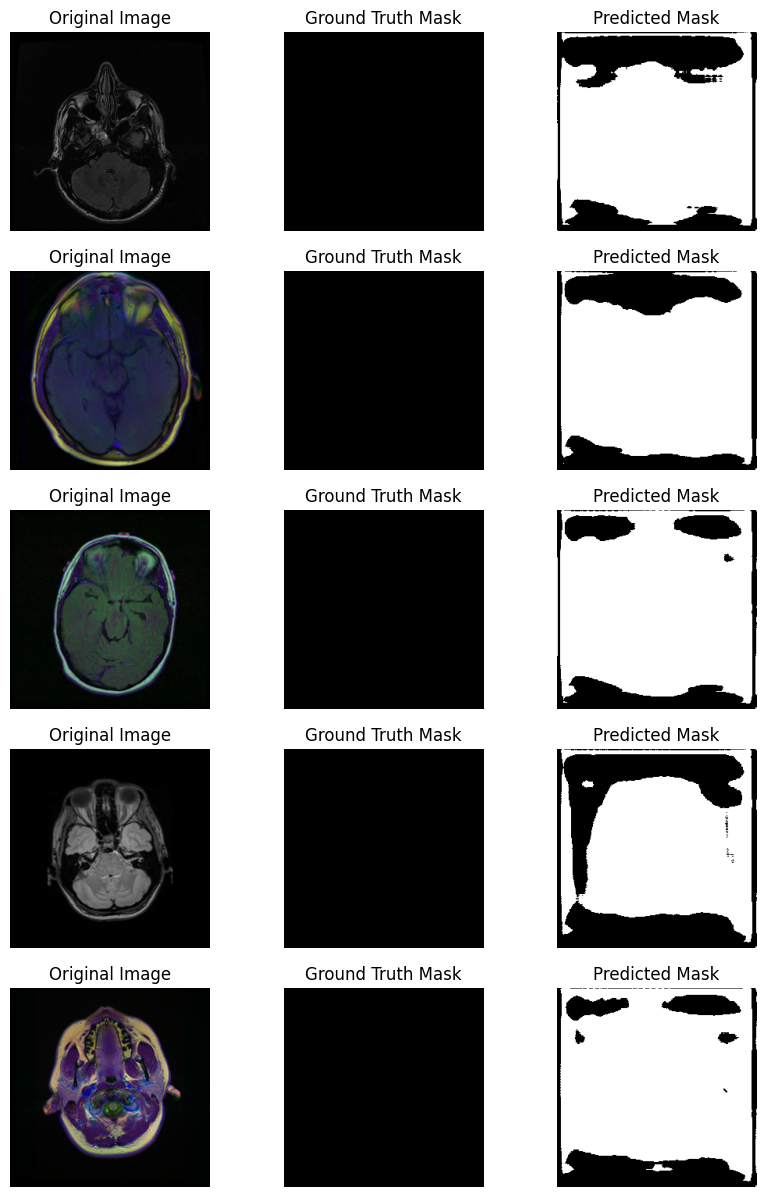

In [ ]:
# Visualizing predictions
import matplotlib.pyplot as plt

def visualize_predictions(model, test_loader, device, num_samples=5):
    model.eval()
    model.to(device)

    images_shown = 0
    plt.figure(figsize=(10, num_samples * 3))

    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)  # Forward pass
            preds = preds.sigmoid()  # Convert logits to probabilities
            preds = (preds > 0.5).float()  # Convert probabilities to binary mask

            for i in range(len(images)):
                if images_shown >= num_samples:
                    plt.show()
                    return
                
                plt.subplot(num_samples, 3, images_shown * 3 + 1)
                plt.imshow(images[i].cpu().squeeze().permute(1, 2, 0))  # Original Image
                plt.title("Original Image")
                plt.axis("off")

                plt.subplot(num_samples, 3, images_shown * 3 + 2)
                plt.imshow(masks[i].cpu().squeeze(), cmap="gray")  # Ground Truth Mask
                plt.title("Ground Truth Mask")
                plt.axis("off")

                plt.subplot(num_samples, 3, images_shown * 3 + 3)
                plt.imshow(preds[i].cpu().squeeze(), cmap="gray")  # Predicted Mask
                plt.title("Predicted Mask")
                plt.axis("off")

                images_shown += 1
                
visualize_predictions(model, test_loader, device, num_samples=5)


-------------------